# Amp Model Trainer
**Инструкция:**
1. Runtime → Change runtime type → **T4 GPU**
2. Загрузи `input.wav` и папку `targets/` через панель Files (иконка папки слева)
3. Запускай ячейки сверху вниз

In [1]:
# Проверка GPU
import tensorflow as tf
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print(f'CUDA: {tf.test.is_built_with_cuda()}')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CUDA: True


In [2]:
# Импорты
import glob, json, os, re
import numpy as np
from scipy.io import wavfile
from scipy.signal import lfilter
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [4]:
# Монтирование google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Параметры
INPUT_WAV    = '/content/drive/MyDrive/input.wav'      # путь к input.wav
TARGETS_DIR  = '/content/drive/MyDrive/targets'        # папка с gain_*.wav

HIDDEN       = 64     # размер GRU
EPOCHS       = 200    # количество эпох
BATCH_SIZE   = 128    # размер мини-выборки
LR           = 4e-4   # шаг обучения, Xe-N = X * 10^-N
SEQ_LEN      = 2048   # размер окна для обучения
VAL_SPLIT    = 0.1

OUT_JSON     = '/content/model.json'
OUT_CKPT     = '/content/best_model.keras'

In [5]:
# Вспомогательные функции
GAIN_VALUES      = [round(g * 0.5, 1) for g in range(21)]
GAIN_VALUES_NORM = [g / 10.0 for g in GAIN_VALUES]

def extract_gain(filepath):
    m = re.search(r'gain_([0-9]+(?:\.[0-9]+)?)', filepath)
    if not m:
        raise ValueError(f'Не удалось разобрать gain из: {filepath}')
    return float(m.group(1))

def load_wav(path):
    sr, data = wavfile.read(path)
    if data.dtype == np.int16:
        data = data.astype(np.float32) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float32) / 2147483648.0
    else:
        data = data.astype(np.float32)
    if data.ndim > 1:
        data = data.mean(axis=1)
    print(f'  {os.path.basename(path)}: sr={sr}, samples={len(data):,}, peak={np.max(np.abs(data)):.4f}')
    return sr, data

In [6]:
# Loss и метрика
# TODO: STFT (MR-STFT loss)
import tensorflow as tf

def preemphasis_tf(x, coef=0.95):
    # Фильтр предыскажений H(z) = 1 - 0.95z^-1
    # Усиливает средние и высокие частоты в loss,
    # чтобы модель лучше училась на них
    # x shape: (batch, seq_len, 1)
    x0 = x[:, :1, :]
    xrest = x[:, 1:, :] - coef * x[:, :-1, :]
    return tf.concat([x0, xrest], axis=1)

def esr_loss(y_true, y_pred):
    eps = 1e-8 # защита от деления на ноль

    # ESR (Error-to-Signal Ratio) с предыскажениями:
    # штрафует за ошибки с акцентом на высокие частоты
    y_true_p = preemphasis_tf(y_true)
    y_pred_p = preemphasis_tf(y_pred)
    esr = tf.reduce_mean(tf.square(y_pred_p - y_true_p)) / (tf.reduce_mean(tf.square(y_true_p)) + eps)
    # DC loss: штрафует за неправильное смещение сигнала от нуля
    # важно для ламповых усилителей с асимметричным клиппингом
    dc = tf.square(tf.reduce_mean(y_pred - y_true)) / (tf.reduce_mean(tf.square(y_true)) + eps)

    return esr + dc

def similarity_metric(y_true, y_pred):
    # Метрика качества: 1.0 = идеально, 0.5 = ESR 100%
    return 1.0 / (1.0 + esr_loss(y_true, y_pred))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2048, 64)       │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048, 1)        │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

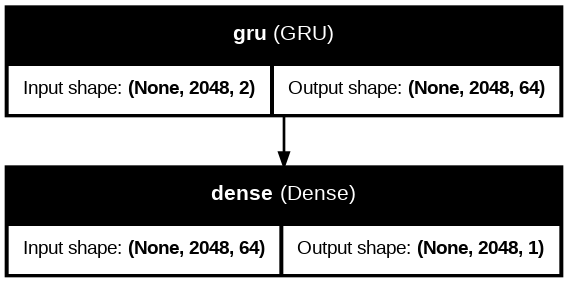

In [7]:
# Модель
def build_model(hidden_size, seq_len, lr):
    model = keras.Sequential() # последовательная модель
    model.add(keras.Input(shape=(seq_len, 2))) # 2 входа, положение ручки gain и аудио

    model.add(layers.GRU(
        hidden_size, return_sequences=True,
        activation='tanh', recurrent_activation='sigmoid',
        reset_after=False, use_bias=True,
        kernel_initializer='glorot_uniform',
        recurrent_initializer='orthogonal',
        bias_initializer='zeros',
    ))
    model.add(layers.Dense(
        1,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
    ))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=lr,
            clipnorm=1.0
            ),
        loss=esr_loss,
        metrics=[similarity_metric]
    )
    return model

model = build_model(HIDDEN, SEQ_LEN, LR)
# Вывод данных о модели
model.summary()
keras.utils.plot_model(
    model,
    to_file='model.png',
    show_shapes=True,        # показывает форму тензоров
    show_layer_names=True,
    show_dtype=False,
    expand_nested=False,
    dpi=96,
)

In [8]:
# Загрузка и препроцессинг данных

# Загрузка аудиофайлов
print('Input:')
sr_in, x_raw = load_wav(INPUT_WAV)

target_files = sorted(
    glob.glob(os.path.join(TARGETS_DIR, 'gain_*.wav')),
    key=extract_gain
)
print(f'Найдено таргетов: {len(target_files)}')

gain_norms = ([extract_gain(f) / 10.0 for f in target_files]
              if len(target_files) != len(GAIN_VALUES) else GAIN_VALUES_NORM)

# Загрузка таргетов в словарь
target_data = {}
for fpath, gnorm in zip(target_files, gain_norms):
    print(f'Target gain_norm={gnorm:.2f}:')
    sr_tg, y_raw = load_wav(fpath)
    assert sr_in == sr_tg, f'Sample rate mismatch: {sr_in} vs {sr_tg}'
    target_data[gnorm] = y_raw

x_proc = x_raw.copy()

data_by_gain = {}

for gnorm, y_raw in target_data.items():
    n = min(len(x_proc), len(y_raw))
    x = x_proc[:n]
    y = y_raw[:n].copy()

    Xg, Yg = [], []

    for i in range(0, n - SEQ_LEN, SEQ_LEN):
        xc = x[i:i+SEQ_LEN].reshape(-1, 1)
        gc = np.full((SEQ_LEN, 1), gnorm, dtype=np.float32)
        Xg.append(np.concatenate([xc, gc], axis=1))
        Yg.append(y[i:i+SEQ_LEN].reshape(-1, 1))

    if len(Xg) > 0:
        data_by_gain[gnorm] = (np.array(Xg, dtype=np.float32),
                              np.array(Yg, dtype=np.float32))
X_train, Y_train = [], []
X_val, Y_val = [], []

for gnorm, (Xg, Yg) in data_by_gain.items():
    idx = np.random.permutation(len(Xg))
    n_val = max(1, int(len(Xg) * VAL_SPLIT))

    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    X_val.append(Xg[val_idx])
    Y_val.append(Yg[val_idx])

    X_train.append(Xg[train_idx])
    Y_train.append(Yg[train_idx])

X_train = np.concatenate(X_train, axis=0)
Y_train = np.concatenate(Y_train, axis=0)
X_val   = np.concatenate(X_val, axis=0)
Y_val   = np.concatenate(Y_val, axis=0)

train_idx = np.random.permutation(len(X_train))
val_idx   = np.random.permutation(len(X_val))

X_train, Y_train = X_train[train_idx], Y_train[train_idx]
X_val,   Y_val   = X_val[val_idx], Y_val[val_idx]

print(f'\nТаргетов: {len(target_data)}')
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

from collections import Counter

train_gains = Counter(X_train[:, 0, 1])
val_gains   = Counter(X_val[:, 0, 1])

print('\nTrain gain distribution:', train_gains)
print('Val gain distribution:', val_gains)

Input:


/tmp/ipykernel_2404/2244502258.py:12: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(path)


  input.wav: sr=48000, samples=9,120,000, peak=0.9900
Найдено таргетов: 21
Target gain_norm=0.00:
  gain_0.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.05:
  gain_0.5.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.10:
  gain_1.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.15:
  gain_1.5.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.20:
  gain_2.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.25:
  gain_2.5.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.30:
  gain_3.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.35:
  gain_3.5.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.40:
  gain_4.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.45:
  gain_4.5.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.50:
  gain_5.0.wav: sr=48000, samples=9,120,000, peak=1.0000
Target gain_norm=0.55:
  gain_5.5.wav: sr=480

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, Y_val))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

callbacks = [
    keras.callbacks.ModelCheckpoint(
        '/content/best_model_epoch{epoch:03d}.keras',
        monitor='val_loss', mode='min',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min',
        factor=0.5, patience=3, min_lr=LR * 0.01, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min',
        patience=10, restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 1.0087 - similarity_metric: 0.4980
Epoch 1: val_loss improved from None to 0.97521, saving model to /content/best_model_epoch001.keras

Epoch 1: finished saving model to /content/best_model_epoch001.keras
658/658 ━━━━━━━━━━━━━━━━━━━━ 160s 235ms/step - loss: 0.9954 - similarity_metric: 0.5012 - val_loss: 0.9752 - val_similarity_metric: 0.5063 - learning_rate: 4.0000e-04
Epoch 2/200
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.9625 - similarity_metric: 0.5096
Epoch 2: val_loss improved from 0.97521 to 0.88391, saving model to /content/best_model_epoch002.keras

Epoch 2: finished saving model to /content/best_model_epoch002.keras
658/658 ━━━━━━━━━━━━━━━━━━━━ 150s 229ms/step - loss: 0.9381 - similarity_metric: 0.5162 - val_loss: 0.8839 - val_similarity_metric: 0.5308 - learning_rate: 4.0000e-04
Epoch 3/200
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.8383 - similarity_metric: 0.5442
Epoch 3: val_loss improved fr

KeyboardInterrupt: 

In [ ]:
# График обучения
best_sim = max(history.history['val_similarity_metric'])
if   best_sim > 0.97: grade = '✅ Отлично'
elif best_sim > 0.95: grade = '🟡 Хорошо'
elif best_sim > 0.90: grade = '🟠 Так себе'
else:                 grade = '❌ Плохо'
print(f'Лучший Val Similarity: {best_sim:.3f}  {grade}')

ep = range(1, len(history.history['similarity_metric']) + 1)
plt.figure(figsize=(10, 4))
plt.plot(ep, history.history['similarity_metric'],     label='Train similarity')
plt.plot(ep, history.history['val_similarity_metric'], label='Val similarity')
plt.xlabel('Epoch')
plt.ylabel('Similarity (1 / (1 + ESR))')
plt.title('Training history')
plt.legend()
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=120)
plt.show()

NameError: name 'history' is not defined

In [ ]:
# Скачать файлы
from google.colab import files
files.download('/content/best_model.keras')
files.download('/content/training_history.png')